In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [5]:
X, y = load_diabetes(as_frame=True, scaled=False, return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
16,47.0,1.0,30.3,109.0,207.0,100.2,70.0,3.00,5.2149,98.0
408,66.0,1.0,21.7,126.0,212.0,127.8,45.0,4.71,5.2781,101.0
432,51.0,1.0,31.5,93.0,231.0,144.0,49.0,4.70,5.2523,117.0
316,53.0,2.0,27.7,95.0,190.0,101.8,41.0,5.00,5.4638,101.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.00,4.8903,89.0


In [8]:
baseline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

baseline.fit(X_train, y_train)

pred_base = baseline.predict(X_test)

mae_base = mean_absolute_error(y_test, pred_base)
rmse_base = root_mean_squared_error(y_test, pred_base)
r2_base = r2_score(y_test, pred_base)

print("BASELINE (StandardScaler + Ridge)")
print("MAE  :", round(mae_base, 3))
print("RMSE :", round(rmse_base, 3))
print("R2   :", round(r2_base, 3))

BASELINE (StandardScaler + Ridge)
MAE  : 41.507
RMSE : 53.318
R2   : 0.486


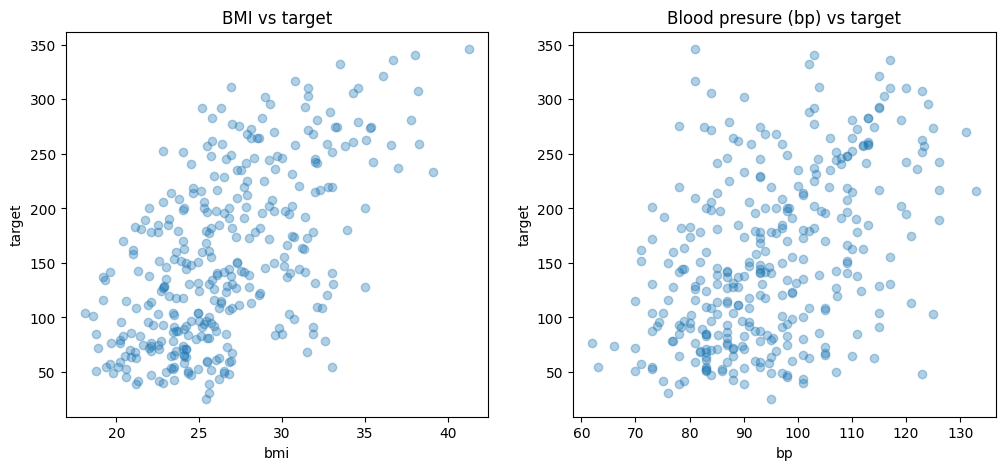

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

axes[0].scatter(X_train["bmi"], y_train, alpha=0.35)
axes[0].set_title("BMI vs target")
axes[0].set_xlabel("bmi")
axes[0].set_ylabel("target")

axes[1].scatter(X_train["bp"], y_train, alpha=0.35)
axes[1].set_title("Blood presure (bp) vs target")
axes[1].set_xlabel("bp")
axes[1].set_ylabel("target")

plt.show()

In [11]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe["risk_index"] = X_train_fe["bmi"] + X_train_fe["bp"]
X_test_fe["risk_index"] = X_test_fe["bmi"] + X_test_fe["bp"]

X_train_fe["bmi_x_bp"] = X_train_fe["bmi"] * X_train_fe["bp"]
X_test_fe["bmi_x_bp"] = X_test_fe["bmi"] * X_test_fe["bp"]

X_train_fe["bmi_sq"] = X_train_fe["bmi"] ** 2
X_test_fe["bmi_sq"] = X_test_fe["bmi"] ** 2

X_train_fe[["risk_index", "bmi_x_bp", "bmi_sq"]].head()

,risk_index,bmi_x_bp,bmi_sq
16,139.3,3302.7,918.09
408,147.7,2734.2,470.89
432,124.5,2929.5,992.25
316,122.7,2631.5,767.29
3,109.3,2125.2,640.09


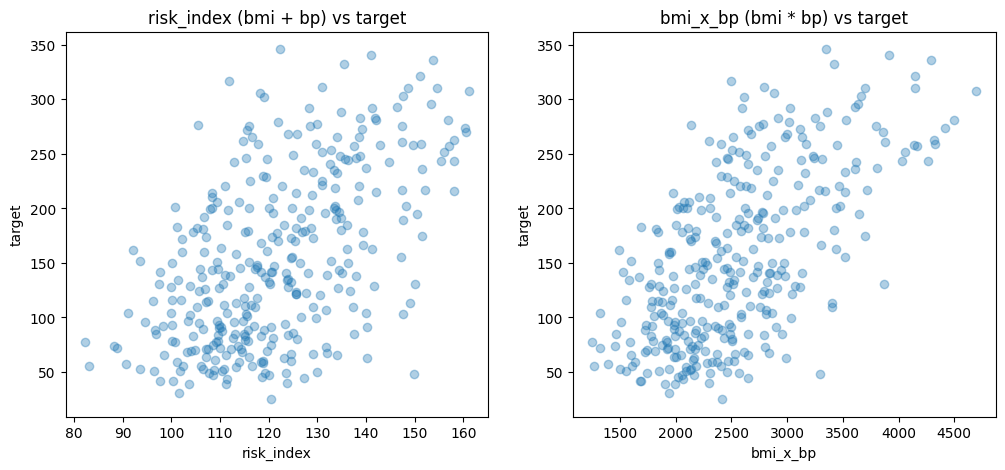

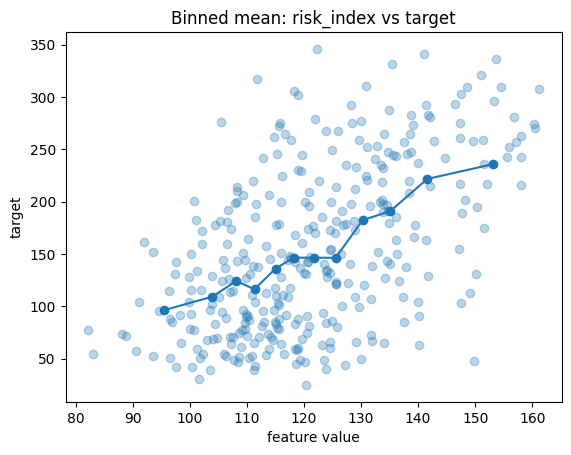

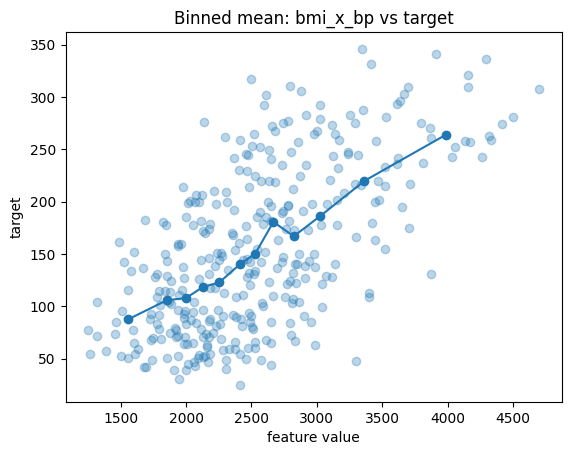

In [13]:
def binned_mean_plot(x, y, bins=12, title=""):
    x = np.asarray(x)
    y = np.asarray(y)

    edges = np.quantile(x, np.linspace(0, 1, bins + 1))
    edges[0] -= 1e-12
    edges[1] += 1e-12

    idx = np.digitize(x, edges[1:-1], right=True)

    x_means = []
    y_means = []
    for b in range(bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        x_means.append(x[mask].mean())
        y_means.append(y[mask].mean())

    plt.figure()
    plt.scatter(x, y, alpha=0.30)
    plt.plot(x_means, y_means, marker="o")
    plt.title(title)
    plt.xlabel("feature value")
    plt.ylabel("target")
    plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

axes[0].scatter(X_train_fe["risk_index"], y_train, alpha=0.35)
axes[0].set_title("risk_index (bmi + bp) vs target")
axes[0].set_xlabel("risk_index")
axes[0].set_ylabel("target")

axes[1].scatter(X_train_fe["bmi_x_bp"], y_train, alpha=0.35)
axes[1].set_title("bmi_x_bp (bmi * bp) vs target")
axes[1].set_xlabel("bmi_x_bp")
axes[1].set_ylabel("target")

plt.show()
binned_mean_plot(X_train_fe["risk_index"], y_train, title="Binned mean: risk_index vs target")
binned_mean_plot(X_train_fe["bmi_x_bp"], y_train, title="Binned mean: bmi_x_bp vs target")

In [14]:
fe_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

fe_model.fit(X_train_fe, y_train)

pred_fe = fe_model.predict(X_test_fe)

mae_fe = mean_absolute_error(y_test, pred_fe)
rmse_fe = root_mean_squared_error(y_test, pred_fe)
r2_fe = r2_score(y_test, pred_fe)

print("FEATURE ENGINEERING   (StandardScaler + Ridge)")
print("MAE  :", round(mae_fe, 3))
print("RMSE :", round(rmse_fe, 3))
print("R2   :", round(r2_fe, 3))

print("\nSkillnad (FE - baseline)")
print("MAE  :", round(mae_fe - mae_base, 3))
print("RMSE :", round(rmse_fe - rmse_base, 3))
print("R2   :", round(r2_fe - r2_base, 3))

FEATURE ENGINEERING   (StandardScaler + Ridge)
MAE  : 41.025
RMSE : 52.627
R2   : 0.499

Skillnad (FE - baseline)
MAE  : -0.482
RMSE : -0.692
R2   : 0.013


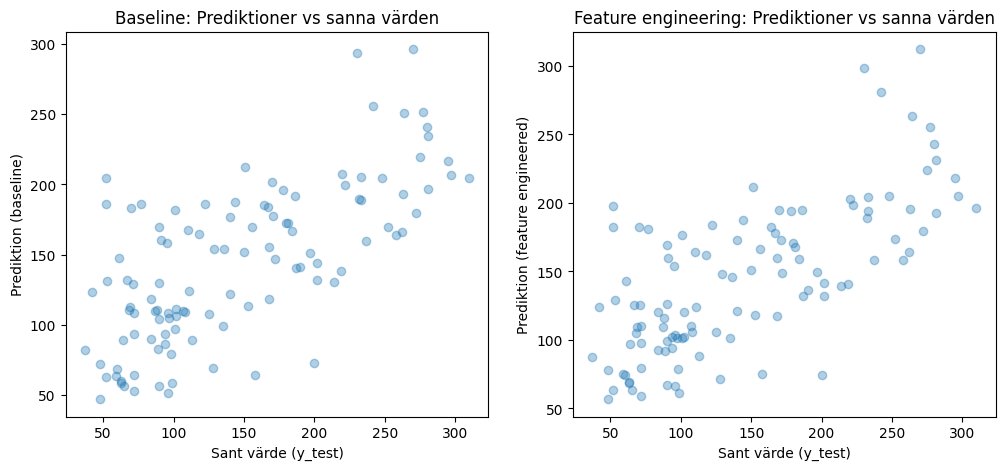

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

axes[0].scatter(y_test, pred_base, alpha=0.35)
axes[0].set_title("Baseline: Prediktioner vs sanna värden")
axes[0].set_xlabel("Sant värde (y_test)")
axes[0].set_ylabel("Prediktion (baseline)")

axes[1].scatter(y_test, pred_fe, alpha=0.35)
axes[1].set_title("Feature engineering: Prediktioner vs sanna värden")
axes[1].set_xlabel("Sant värde (y_test)")
axes[1].set_ylabel("Prediktion (feature engineered)")

plt.show()

In [16]:
pipe_poly = Pipeline(steps=[
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {
    "poly__degree": [1, 2],
    "model__alpha": [0.1, 1.0, 10.0, 100.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_poly,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_poly = grid.best_estimator_
pred_poly = best_poly.predict(X_test)

rmse_poly = root_mean_squared_error(y_test, pred_poly)

print("Bästa params:", grid.best_params_)
print("RMSE (PolynomialFeatures + Ridge):", round(rmse_poly, 3))
print("RMSE baseline:", round(rmse_base, 3))
print("RMSE feature engieered:", round(rmse_fe, 3))

Bästa params: {'model__alpha': 100.0, 'poly__degree': 2}
RMSE (PolynomialFeatures + Ridge): 53.2
RMSE baseline: 53.318
RMSE feature engieered: 52.627
